### Concepts shown in this demo notebook:

* Demonstrating how to use PCTrees as a back bone of traditional generative models.  

**Things to try:**
* Try different `max_width` and `max_nodes` and see how that effects what kind of data is generated.
* Look at the implementations in `pctree.generation`.

## Imports

In [1]:
import sys; sys.path.insert(0, "..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pctree.core import PCTreeCoefficients
from pctree.training import PCTreeTrainerOptions, PCTreeTrainer
from pctree.branches import EfficientEncodingRouter
from pctree.pruning import EfficientEncodingPruner

from pctree.generation import *

import warnings
warnings.filterwarnings('ignore')


## Load MNIST Digits

In [4]:
mnist_X = np.load("../data/mnist_train.npy").astype(np.float32)
X_mean = mnist_X.mean(axis=0)
mnist_X -= X_mean

## Learn a 100-Node, 10-Branch PCT

In [5]:
training_options=PCTreeTrainerOptions(
    max_nodes=100, 
    max_width=10,
    max_children=5,
    sifting_effect_size=0.6,
    variance_capture_percent=0.990,
    pruner=EfficientEncodingPruner(),
)

In [6]:
trainer = PCTreeTrainer(
    PCTreeTrainerOptions(
        max_nodes=100, 
        max_width=10,
        max_children=5,
        sifting_effect_size=0.6,
        variance_capture_percent=0.990,
        pruner=EfficientEncodingPruner())
)
trainer.fit_partition(mnist_X, verbose=1)
tree = trainer.fit_em(mnist_X, X_topdown=mnist_X, verbose=1, n_iters=5)

Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
--<-<--<<<<<-<-<
[Branch Assignment]|||||| 60000 points assigned in 1.15s. 
[Fixed-shape PCT Reweighting] ΣΣΣΣΣΣΣΣΣΣλλλλλλλλλλλλλλ Reweighting using 60000 points in 0.48s. 
[Branch Assignment]|||||| 60000 points assigned in 0.22s. 
[Branch Assignment]|||||| 60000 points assigned in 0.28s. 


In [6]:
best_branch = EfficientEncodingRouter(tree, verbose=1).predict(mnist_X)
branches = tree.branches()
random_branches = BranchAssignmentGenerator(best_branch)

C = PCTreeCoefficients(tree, mnist_X, best_branch)

## PCA (PCT with one branch)

In [7]:
tree_pca = PCTreeTrainer.from_pca(mnist_X, n_components=100)
C_pca = PCTreeCoefficients(tree_pca, mnist_X, np.zeros(mnist_X.shape[0], dtype=int))

## PCA-Based Models

In [10]:
GM_PCA_Simple = NodeWiseGenerativeModel(lambda: NormalGenerativeModel())
GM_PCA_Simple.fit(C_pca)
GM_PCA_Simple.num_params()

200

In [11]:
GM_PCA_GMMTied = BranchwiseGenerativeModel(lambda: GMMBranchGenerativeModel(7, covariance_type="tied"))
GM_PCA_GMMTied.fit(C_pca)
GM_PCA_GMMTied.num_params()

5756

In [12]:
GM_PCA_GMMFull = BranchwiseGenerativeModel(lambda: GMMBranchGenerativeModel(7, covariance_type="full"))
GM_PCA_GMMFull.fit(C_pca)
GM_PCA_GMMFull.num_params()

36056

## PCT-Based Models

In [13]:
GM_Nodewise_Simple = NodeWiseGenerativeModel(lambda: NormalGenerativeModel())
GM_Nodewise_Simple.fit(C)
GM_Nodewise_Simple.num_params()

200

In [14]:
# Not displayed. Just using a better 1D model per node.
GM_Nodewise = NodeWiseGenerativeModel(lambda: GMM1DGenerativeModel(n_components=7))
GM_Nodewise.fit(C)
GM_Nodewise.num_params()

2000

In [15]:
# Not displayed. Just using a better 1D model per node, per branch
GM_BranchWise_Nodewise = BranchwiseGenerativeModel(
    lambda: BayesBranchGenerativeModel(lambda: GMM1DGenerativeModel(n_components=7))
)
GM_BranchWise_Nodewise.fit(C)
GM_BranchWise_Nodewise.num_params()

2600

In [16]:
GM_BranchWise_NodewiseSimp = BranchwiseGenerativeModel(
    lambda: BayesBranchGenerativeModel(lambda: NormalGenerativeModel())
)
GM_BranchWise_NodewiseSimp.fit(C)
GM_BranchWise_NodewiseSimp.num_params()

260

In [17]:
GM_BranchWise_Full = BranchwiseGenerativeModel(
    lambda: GMMBranchGenerativeModel(7, covariance_type="full")
)
GM_BranchWise_Full.fit(C)
GM_BranchWise_Full.num_params()

7788

In [18]:
GM_BranchWise_Diag = BranchwiseGenerativeModel(
    lambda: GMMBranchGenerativeModel(7, covariance_type="diag")
)
GM_BranchWise_Diag.fit(C)
GM_BranchWise_Diag.num_params()

1880

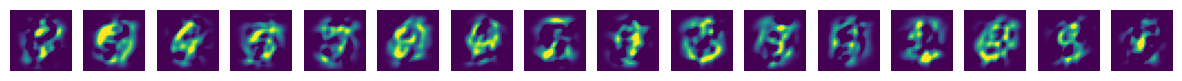

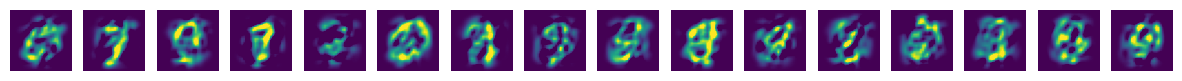

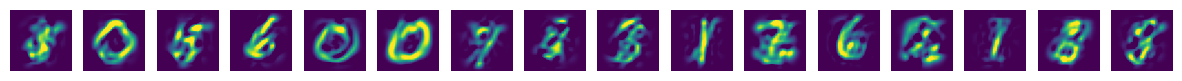

In [19]:
generative_models = [
    GM_PCA_Simple,
    GM_PCA_GMMTied,
    GM_PCA_GMMFull,
]

for i in range(3):
    fig, axes = plt.subplots(1, 16, figsize=(15, 3))
    model = generative_models[i]
    X_generated = model.generate(np.zeros(1500, dtype=int)).reconstruct()
    for ax_i, ax in enumerate(axes):
        ax.set_axis_off()
        ax.imshow((X_generated[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255)

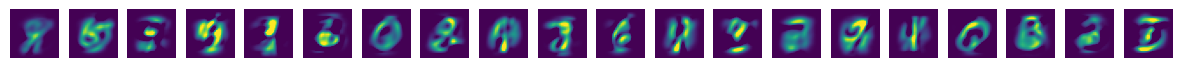

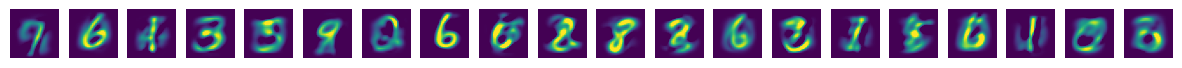

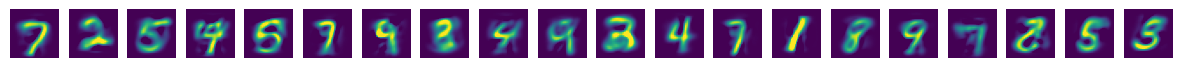

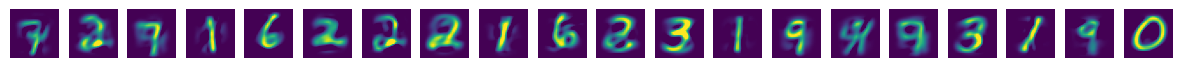

In [20]:
generative_models = [
    GM_Nodewise_Simple,
    GM_BranchWise_NodewiseSimp,
    GM_BranchWise_Full,
    GM_BranchWise_Diag
]

for i in range(4):
    fig, axes = plt.subplots(1, 20, figsize=(15, 3))
    model = generative_models[i]
    X_generated = model.generate(random_branches.generate(1000)).reconstruct()
    for ax_i, ax in enumerate(axes):
        ax.set_axis_off()
        ax.imshow((X_generated[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255)